   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


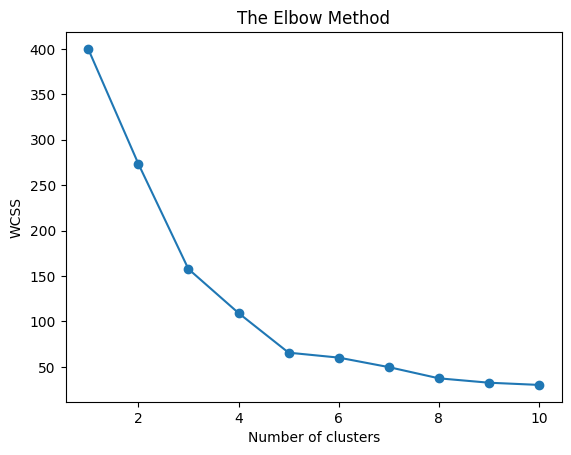

Number of clusters: 2, Silhouette score: 0.3973270007887498
Number of clusters: 3, Silhouette score: 0.46658474419000145
Number of clusters: 4, Silhouette score: 0.49434988482196784
Number of clusters: 5, Silhouette score: 0.5546571631111091
Number of clusters: 6, Silhouette score: 0.5138257534676561
Number of clusters: 7, Silhouette score: 0.50200146805547
Number of clusters: 8, Silhouette score: 0.4550112502601921
Number of clusters: 9, Silhouette score: 0.4566624374485964
Number of clusters: 10, Silhouette score: 0.44475993501732874


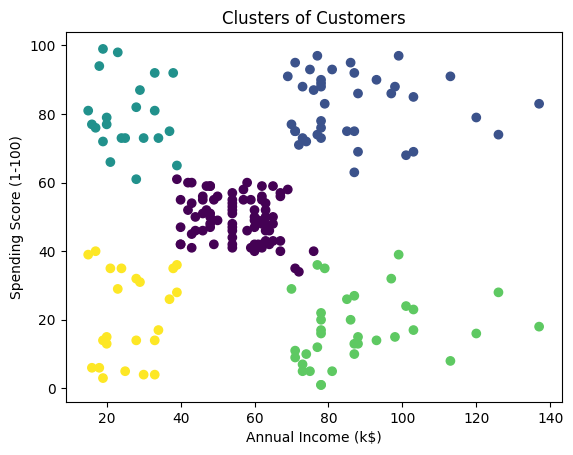

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df = pd.read_csv('Mall_Customers.csv')

print(df.head())

X = df.iloc[:, [3, 4]].values
scalared = StandardScaler()
X = scalared.fit_transform(X)

wcss = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)

  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss,marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

for k in range(2, 11):
  kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
  labels = kmeans.fit_predict(X)
  score = silhouette_score(X, labels)
  print(f"Number of clusters: {k}, Silhouette score: {score}")

  kmeans = KMeans(n_clusters=5,init='k-means++', random_state=42)
  labels = kmeans.fit_predict(X)

  df["Cluster"] = labels

plt.scatter(x=df["Annual Income (k$)"], y=df["Spending Score (1-100)"], c=df["Cluster"]) # Added closing parenthesis
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Clusters of Customers")
plt.show()